<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Locked_Elastic_Scattering_Shape_Test_V32_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V32 — Locked Elastic Scattering Shape Test

This notebook implements a locked non-doorway elastic scattering shape test for the ECSM electron-like packet sequence.

It inherits the V21b--V31 frozen packet values and the V29 finite-transfer scattering-amplitude structure. The test compares a locked ECSM elastic angular shape against an externally specified Rutherford/Mott-like theoretical reference over fixed kinetic energies and angles. No measured scattering data are used as a fit, and no parameters are adjusted after comparison.

In [23]:

# CELL 1 — SETUP AND FROZEN V21b--V31 HANDOFF
import json, math, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('/content/ecsm_electron_like_locked_elastic_scattering_shape_v32_out')
OUT.mkdir(parents=True, exist_ok=True)
run_label = 'V32_locked_non_doorway_elastic_scattering_shape_test'

# Frozen inherited packet values from V21b--V31
q_eff = -0.9993035720499918
E_rest_keV_from_V21b = 514.0698767738036
electron_rest_energy_target_keV_comparison_only = 510.9989506917532
alpha_fs_input = 0.0072973525692838015
k_response_chi1_keV = 5140.698767738036
Pi_ecsm_plateau_locked = 0.007146727844882419

handoff = {
    'source_chain': 'V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27 -> V27b -> V28 -> V29 -> V30 -> V31',
    'q_eff': q_eff,
    'E_rest_keV_from_V21b': E_rest_keV_from_V21b,
    'electron_rest_energy_target_keV_comparison_only': electron_rest_energy_target_keV_comparison_only,
    'alpha_fs_input': alpha_fs_input,
    'k_response_chi1_keV': k_response_chi1_keV,
    'Pi_ecsm_plateau_locked': Pi_ecsm_plateau_locked,
    'V29_input': 'finite elastic scattering-amplitude doorway',
    'V30_input': 'radiative/amplitude stack consistency freeze audit',
    'V31_input': 'locked running-response theoretical-reference test',
    'V32_claim_target': 'locked elastic scattering shape test',
    'measured_scattering_data_used_as_fit': False,
    'parameters_adjusted_after_comparison': False,
    'doorway_claimed': False,
}

(OUT/'v21b_to_v31_locked_handoff_v32.json').write_text(json.dumps(handoff, indent=2))
print(json.dumps(handoff, indent=2))

{
  "source_chain": "V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27 -> V27b -> V28 -> V29 -> V30 -> V31",
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "electron_rest_energy_target_keV_comparison_only": 510.9989506917532,
  "alpha_fs_input": 0.0072973525692838015,
  "k_response_chi1_keV": 5140.698767738036,
  "Pi_ecsm_plateau_locked": 0.007146727844882419,
  "V29_input": "finite elastic scattering-amplitude doorway",
  "V30_input": "radiative/amplitude stack consistency freeze audit",
  "V31_input": "locked running-response theoretical-reference test",
  "V32_claim_target": "locked elastic scattering shape test",
  "measured_scattering_data_used_as_fit": false,
  "parameters_adjusted_after_comparison": false,
  "doorway_claimed": false
}


In [24]:

# CELL 2 — LOCKED FORMULAE AND EXTERNALLY SPECIFIED REFERENCE
# The reference is a Rutherford/Mott-like theoretical shape; it is not measured scattering data.

m_keV = E_rest_keV_from_V21b
alpha = alpha_fs_input
kc = k_response_chi1_keV
Pi_plateau = Pi_ecsm_plateau_locked
Z = 1.0

# Fixed angular/kinetic grid chosen before evaluation.
T_values_keV = np.array([10.0, 100.0, 1000.0, 5000.0])
theta_deg = np.linspace(1.0, 179.0, 800)

def momentum_keV(T, m=m_keV):
    return np.sqrt(T*(T + 2*m))

def beta_rel(T, m=m_keV):
    p = momentum_keV(T, m)
    E = T + m
    return p/E

def pi_reference(q):
    q = np.asarray(q, dtype=float)
    return (2*alpha/(3*np.pi)) * np.log1p((q/m_keV)**2)

def pi_ecsm_locked(q, chi=1.0):
    # Saturating V28/V31 locked response: follows the leading-log reference at low q and plateaus at high q.
    pref = pi_reference(q)
    # Coherence deformation lowers the plateau scale smoothly without refitting.
    plateau = Pi_plateau * (0.65 + 0.35*chi)
    return plateau * (1 - np.exp(-pref/plateau))

def alpha_ref(q):
    pref = pi_reference(q)
    return alpha/(1 - pref)

def alpha_ecsm(q, chi=1.0):
    pecsm = pi_ecsm_locked(q, chi=chi)
    return alpha/(1 - pecsm)

def transfer_form_factor(q, chi=1.0):
    # V29 frozen finite-transfer form factor, n=1.
    kchi = kc * (0.3 + 0.7*chi)
    return 1/(1 + q/kchi)

def mott_spin_factor(theta_rad, beta):
    return 1 - beta**2 * np.sin(theta_rad/2)**2

def ref_shape(T, theta_rad):
    p = momentum_keV(T)
    beta = beta_rel(T)
    q = 2*p*np.sin(theta_rad/2)
    # reference amplitude shape: alpha_ref(q)/q^2, spin factor in cross-section
    A = Z * alpha_ref(q) / (q**2)
    S = mott_spin_factor(theta_rad, beta)
    sigma = (A**2) * S
    return q, S, sigma

def ecsm_shape(T, theta_rad, chi=1.0):
    p = momentum_keV(T)
    beta = beta_rel(T)
    q = 2*p*np.sin(theta_rad/2)
    A_ref = Z * alpha_ref(q) / (q**2)
    R_alpha = alpha_ecsm(q, chi=chi) / alpha_ref(q)
    F = transfer_form_factor(q, chi=chi)
    A_ecsm = A_ref * R_alpha * F
    S = mott_spin_factor(theta_rad, beta)
    sigma = (A_ecsm**2) * S
    return q, S, sigma, F, R_alpha

reference_summary = {
    'T_values_keV': T_values_keV.tolist(),
    'theta_min_deg': float(theta_deg.min()),
    'theta_max_deg': float(theta_deg.max()),
    'reference_type': 'externally specified Rutherford/Mott-like theoretical shape',
    'measured_scattering_data_used_as_fit': False,
    'parameters_adjusted_after_comparison': False,
}
(OUT/'locked_scattering_reference_definition_v32.json').write_text(json.dumps(reference_summary, indent=2))
print(json.dumps(reference_summary, indent=2))


{
  "T_values_keV": [
    10.0,
    100.0,
    1000.0,
    5000.0
  ],
  "theta_min_deg": 1.0,
  "theta_max_deg": 179.0,
  "reference_type": "externally specified Rutherford/Mott-like theoretical shape",
  "measured_scattering_data_used_as_fit": false,
  "parameters_adjusted_after_comparison": false
}


In [25]:

# CELL 3 — LOCKED ANGULAR SHAPE PROFILES
rows = []
theta_rad = np.deg2rad(theta_deg)
for T in T_values_keV:
    q, S, sig_ref = ref_shape(T, theta_rad)
    _, _, sig_ecsm, F, R_alpha = ecsm_shape(T, theta_rad, chi=1.0)
    # Normalize each T to the reference shape at 90 degrees for shape-only comparison.
    i90 = int(np.argmin(np.abs(theta_deg - 90.0)))
    norm = sig_ref[i90]
    sig_ref_n = sig_ref/norm
    sig_ecsm_n = sig_ecsm/norm
    ratio = sig_ecsm / sig_ref
    rel_diff = np.abs(sig_ecsm_n - sig_ref_n) / np.maximum(np.abs(sig_ref_n), 1e-300)
    for i in range(len(theta_deg)):
        rows.append({
            'T_keV': float(T),
            'theta_deg': float(theta_deg[i]),
            'p_keV': float(momentum_keV(T)),
            'beta_rel': float(beta_rel(T)),
            'q_transfer_keV': float(q[i]),
            'mott_spin_factor': float(S[i]),
            'sigma_ref_norm_to_ref90': float(sig_ref_n[i]),
            'sigma_ecsm_norm_to_ref90': float(sig_ecsm_n[i]),
            'ratio_ecsm_to_ref': float(ratio[i]),
            'relative_shape_difference': float(rel_diff[i]),
            'transfer_form_factor': float(F[i]),
            'running_alpha_ratio': float(R_alpha[i]),
        })

shape_df = pd.DataFrame(rows)
shape_df.to_csv(OUT/'locked_elastic_scattering_shape_profiles_v32.csv', index=False)

summary = {
    'n_rows': int(len(shape_df)),
    'all_values_finite': bool(np.isfinite(shape_df.select_dtypes(include=[float, int]).to_numpy()).all()),
    'q_min_keV': float(shape_df['q_transfer_keV'].min()),
    'q_max_keV': float(shape_df['q_transfer_keV'].max()),
    'minimum_mott_spin_factor': float(shape_df['mott_spin_factor'].min()),
    'maximum_mott_spin_factor': float(shape_df['mott_spin_factor'].max()),
}
(OUT/'locked_elastic_scattering_shape_profiles_summary_v32.json').write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
shape_df.head()


{
  "n_rows": 3200,
  "all_values_finite": true,
  "q_min_keV": 1.7782784529319688,
  "q_max_keV": 10979.69097571184,
  "minimum_mott_spin_factor": 0.008767091536951432,
  "maximum_mott_spin_factor": 0.9999971215337196
}


,T_keV,theta_deg,p_keV,beta_rel,q_transfer_keV,mott_spin_factor,sigma_ref_norm_to_ref90,sigma_ecsm_norm_to_ref90,ratio_ecsm_to_ref,relative_shape_difference,transfer_form_factor,running_alpha_ratio
0,10.0,1.000000,101.889143,0.194419,1.778278,0.999997,4.410208e+07,4.407159e+07,0.999309,0.000691,0.999654,1.0
1,10.0,1.222778,101.889143,0.194419,2.174427,0.999996,1.972778e+07,1.971110e+07,0.999155,0.000845,0.999577,1.0
2,10.0,1.445557,101.889143,0.194419,2.570567,0.999994,1.010046e+07,1.009036e+07,0.999001,0.000999,0.999500,1.0
3,10.0,1.668335,101.889143,0.194419,2.966698,0.999992,5.693283e+06,5.686717e+06,0.998847,0.001153,0.999423,1.0
4,10.0,1.891114,101.889143,0.194419,3.362817,0.999990,3.448593e+06,3.444086e+06,0.998693,0.001307,0.999346,1.0


In [26]:

# CELL 4 — LOW-TRANSFER SHAPE CORRESPONDENCE AUDIT
# Locked low-transfer comparison range inherited from V29 low-transfer audit.
q_low_max = 1268.2050944324717
low_df = shape_df[shape_df['q_transfer_keV'] <= q_low_max].copy()

low_summary = {
    'q_low_max_keV': q_low_max,
    'n_low_transfer_points': int(len(low_df)),
    'max_low_transfer_shape_relative_difference': float(low_df['relative_shape_difference'].max()),
    'mean_low_transfer_shape_relative_difference': float(low_df['relative_shape_difference'].mean()),
    'median_low_transfer_shape_relative_difference': float(low_df['relative_shape_difference'].median()),
    'passes_low_transfer_max_threshold_0p06': bool(low_df['relative_shape_difference'].max() <= 0.06),
    'passes_low_transfer_mean_threshold_0p005': bool(low_df['relative_shape_difference'].mean() <= 0.005),
}
low_df.to_csv(OUT/'low_transfer_locked_scattering_shape_correspondence_v32.csv', index=False)
(OUT/'low_transfer_locked_scattering_shape_correspondence_summary_v32.json').write_text(json.dumps(low_summary, indent=2))
print(json.dumps(low_summary, indent=2))
low_df.tail()


{
  "q_low_max_keV": 1268.2050944324717,
  "n_low_transfer_points": 1889,
  "max_low_transfer_shape_relative_difference": 0.35709712178889474,
  "mean_low_transfer_shape_relative_difference": 0.11318908339206013,
  "median_low_transfer_shape_relative_difference": 0.07444301709794611,
  "passes_low_transfer_max_threshold_0p06": false,
  "passes_low_transfer_mean_threshold_0p005": false
}


,T_keV,theta_deg,p_keV,beta_rel,q_transfer_keV,mott_spin_factor,sigma_ref_norm_to_ref90,sigma_ecsm_norm_to_ref90,ratio_ecsm_to_ref,relative_shape_difference,transfer_form_factor,running_alpha_ratio
2451,5000.0,12.361702,5490.054532,0.995645,1182.196418,0.988509,3626.699212,2394.911562,0.660356,0.339644,0.813029,0.999500
2452,5000.0,12.584481,5490.054532,0.995645,1203.416612,0.988092,3376.475888,2214.715839,0.655925,0.344075,0.810310,0.999485
2453,5000.0,12.807259,5490.054532,0.995645,1224.632257,0.987669,3147.448692,2050.688826,0.651540,0.348460,0.807609,0.999469
2454,5000.0,13.030038,5490.054532,0.995645,1245.843273,0.987238,2937.499382,1901.147933,0.647199,0.352801,0.804927,0.999454
2455,5000.0,13.252816,5490.054532,0.995645,1267.049581,0.986800,2744.752622,1764.609361,0.642903,0.357097,0.802263,0.999438


In [27]:

# CELL 5 — LARGE-ANGLE / HIGH-TRANSFER SUPPRESSION AUDIT ON FIXED ANGULAR GRID
# The fixed angular test grid reaches q ~ 1.1e4 keV at T=5000 keV, not the extreme 1e8 keV transfer grid of V29.
# The required locked-scattering criterion is finite large-transfer suppression on the fixed angular range.
large_df = shape_df[(shape_df['T_keV'] == 5000.0) & (shape_df['theta_deg'] >= 120.0)].copy()
max_q_row = shape_df.loc[shape_df['q_transfer_keV'].idxmax()].to_dict()

large_summary = {
    'fixed_grid_q_max_keV': float(shape_df['q_transfer_keV'].max()),
    'ratio_ecsm_to_ref_at_fixed_grid_qmax': float(max_q_row['ratio_ecsm_to_ref']),
    'theta_at_fixed_grid_qmax_deg': float(max_q_row['theta_deg']),
    'T_at_fixed_grid_qmax_keV': float(max_q_row['T_keV']),
    'mean_ratio_large_angle_T5000_theta_ge_120': float(large_df['ratio_ecsm_to_ref'].mean()),
    'min_ratio_large_angle_T5000_theta_ge_120': float(large_df['ratio_ecsm_to_ref'].min()),
    'max_ratio_large_angle_T5000_theta_ge_120': float(large_df['ratio_ecsm_to_ref'].max()),
    'finite_large_angle_suppression_pass': bool(max_q_row['ratio_ecsm_to_ref'] < 0.25 and max_q_row['ratio_ecsm_to_ref'] > 0),
}
large_df.to_csv(OUT/'large_angle_locked_scattering_suppression_v32.csv', index=False)
(OUT/'large_angle_locked_scattering_suppression_summary_v32.json').write_text(json.dumps(large_summary, indent=2))
print(json.dumps(large_summary, indent=2))
large_df.tail()


{
  "fixed_grid_q_max_keV": 10979.69097571184,
  "ratio_ecsm_to_ref_at_fixed_grid_qmax": 0.1008297207504789,
  "theta_at_fixed_grid_qmax_deg": 179.0,
  "T_at_fixed_grid_qmax_keV": 5000.0,
  "mean_ratio_large_angle_T5000_theta_ge_120": 0.10768157975931303,
  "min_ratio_large_angle_T5000_theta_ge_120": 0.1008297207504789,
  "max_ratio_large_angle_T5000_theta_ge_120": 0.1220202129885171,
  "finite_large_angle_suppression_pass": true
}


,T_keV,theta_deg,p_keV,beta_rel,q_transfer_keV,mott_spin_factor,sigma_ref_norm_to_ref90,sigma_ecsm_norm_to_ref90,ratio_ecsm_to_ref,relative_shape_difference,transfer_form_factor,running_alpha_ratio
3195,5000.0,178.108886,5490.054532,0.995645,10978.613873,0.008962,0.004480,0.000452,0.100843,0.899157,0.318916,0.995744
3196,5000.0,178.331665,5490.054532,0.995645,10978.945393,0.008902,0.004450,0.000449,0.100839,0.899161,0.318909,0.995744
3197,5000.0,178.554443,5490.054532,0.995645,10979.235417,0.008849,0.004423,0.000446,0.100835,0.899165,0.318903,0.995744
3198,5000.0,178.777222,5490.054532,0.995645,10979.483945,0.008804,0.004400,0.000444,0.100832,0.899168,0.318898,0.995744
3199,5000.0,179.000000,5490.054532,0.995645,10979.690976,0.008767,0.004381,0.000442,0.100830,0.899170,0.318894,0.995744


In [28]:

# CELL 6 — EXTREME-TRANSFER CONSISTENCY CHECK inherited from V29 form factor
# This is not the angular-shape comparison itself; it confirms that the frozen amplitude structure remains finite on an extended q grid.
q_grid = np.geomspace(1e-2, 1e8, 1600)
Aref = alpha_ref(q_grid)/(q_grid**2)
Recsm = (alpha_ecsm(q_grid)/alpha_ref(q_grid))*transfer_form_factor(q_grid)
Aecsm = Aref*Recsm
ratio = Aecsm/Aref
sig_ratio = ratio**2
extreme_summary = {
    'q_min_keV': float(q_grid.min()),
    'q_max_keV': float(q_grid.max()),
    'all_amplitudes_finite': bool(np.isfinite(Aref).all() and np.isfinite(Aecsm).all()),
    'amplitude_ratio_at_1e8_keV': float(ratio[-1]),
    'cross_section_ratio_at_1e8_keV': float(sig_ratio[-1]),
    'passes_extreme_transfer_finite_suppression': bool(sig_ratio[-1] < 1e-6 and sig_ratio[-1] > 0),
}
extreme_df = pd.DataFrame({'q_keV': q_grid, 'amplitude_ratio_ecsm_to_ref': ratio, 'cross_section_ratio_ecsm_to_ref': sig_ratio})
extreme_df.to_csv(OUT/'extreme_transfer_locked_scattering_consistency_v32.csv', index=False)
(OUT/'extreme_transfer_locked_scattering_consistency_summary_v32.json').write_text(json.dumps(extreme_summary, indent=2))
print(json.dumps(extreme_summary, indent=2))
extreme_df.tail()


{
  "q_min_keV": 0.01,
  "q_max_keV": 100000000.0,
  "all_amplitudes_finite": true,
  "amplitude_ratio_at_1e8_keV": 4.9819737968361934e-05,
  "cross_section_ratio_at_1e8_keV": 2.4820062912362438e-09,
  "passes_extreme_transfer_finite_suppression": true
}


,q_keV,amplitude_ratio_ecsm_to_ref,cross_section_ratio_ecsm_to_ref
1595,9.440269e+07,0.000053,2.786068e-09
1596,9.577194e+07,0.000052,2.706727e-09
1597,9.716105e+07,0.000051,2.629646e-09
1598,9.857030e+07,0.000051,2.554760e-09
1599,1.000000e+08,0.000050,2.482006e-09


In [29]:

# CELL 7 — CHI DEFORMATION AUDIT
chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
chi_rows = []
probe_T = 5000.0
probe_theta = np.deg2rad(np.array([30, 60, 90, 120, 150, 179], dtype=float))
for chi in chi_values:
    q, S, sig_ref = ref_shape(probe_T, probe_theta)
    _, _, sig_ecsm, F, R_alpha = ecsm_shape(probe_T, probe_theta, chi=chi)
    ratio = sig_ecsm/sig_ref
    for i, th in enumerate(np.rad2deg(probe_theta)):
        chi_rows.append({
            'chi': chi,
            'T_keV': probe_T,
            'theta_deg': float(th),
            'q_transfer_keV': float(q[i]),
            'cross_section_ratio_ecsm_to_ref': float(ratio[i]),
            'transfer_form_factor': float(F[i]),
            'running_alpha_ratio': float(R_alpha[i]),
        })
chi_df = pd.DataFrame(chi_rows)
chi_summary = {
    'chi_values': chi_values,
    'finite_all_chi': bool(np.isfinite(chi_df.select_dtypes(include=[float, int]).to_numpy()).all()),
    'min_cross_section_ratio': float(chi_df['cross_section_ratio_ecsm_to_ref'].min()),
    'max_cross_section_ratio': float(chi_df['cross_section_ratio_ecsm_to_ref'].max()),
}
chi_df.to_csv(OUT/'chi_deformation_locked_scattering_shape_v32.csv', index=False)
(OUT/'chi_deformation_locked_scattering_shape_summary_v32.json').write_text(json.dumps(chi_summary, indent=2))
print(json.dumps(chi_summary, indent=2))
chi_df.head()


{
  "chi_values": [
    1.0,
    0.95,
    0.8,
    0.5,
    0.2
  ],
  "finite_all_chi": true,
  "min_cross_section_ratio": 0.028877601228932907,
  "max_cross_section_ratio": 0.41340903438154675
}


,chi,T_keV,theta_deg,q_transfer_keV,cross_section_ratio_ecsm_to_ref,transfer_form_factor,running_alpha_ratio
0,1.0,5000.0,30.0,2841.861343,0.413409,0.643991,0.998413
1,1.0,5000.0,60.0,5490.054532,0.232545,0.483569,0.997230
2,1.0,5000.0,90.0,7764.109578,0.157582,0.398355,0.996513
3,1.0,5000.0,120.0,9509.053386,0.122169,0.350907,0.996069
4,1.0,5000.0,150.0,10605.970921,0.105689,0.326463,0.995823


In [30]:

# CELL 8 — NO-FIT / NO-OVERCLAIM AUDIT
no_fit = {
    'measured_scattering_cross_sections_used_as_fit': False,
    'measured_scattering_cross_sections_used_for_parameter_selection': False,
    'parameters_adjusted_after_comparison': False,
    'measured_running_alpha_used_as_fit': False,
    'electron_mass_repaired_or_refit': False,
    'full_QED_scattering_claimed': False,
    'renormalised_S_matrix_claimed': False,
    'precision_Mott_or_Rutherford_prediction_claimed': False,
    'doorway_claimed': False,
    'failure_allowed_by_protocol': True,
    'interpretation': 'V32 is a locked theoretical-reference elastic scattering shape test, not measured scattering-data fitting and not a full-QED scattering calculation.'
}
(OUT/'no_fit_no_overclaim_audit_v32.json').write_text(json.dumps(no_fit, indent=2))
print(json.dumps(no_fit, indent=2))


{
  "measured_scattering_cross_sections_used_as_fit": false,
  "measured_scattering_cross_sections_used_for_parameter_selection": false,
  "parameters_adjusted_after_comparison": false,
  "measured_running_alpha_used_as_fit": false,
  "electron_mass_repaired_or_refit": false,
  "full_QED_scattering_claimed": false,
  "renormalised_S_matrix_claimed": false,
  "precision_Mott_or_Rutherford_prediction_claimed": false,
  "doorway_claimed": false,
  "failure_allowed_by_protocol": true,
  "interpretation": "V32 is a locked theoretical-reference elastic scattering shape test, not measured scattering-data fitting and not a full-QED scattering calculation."
}


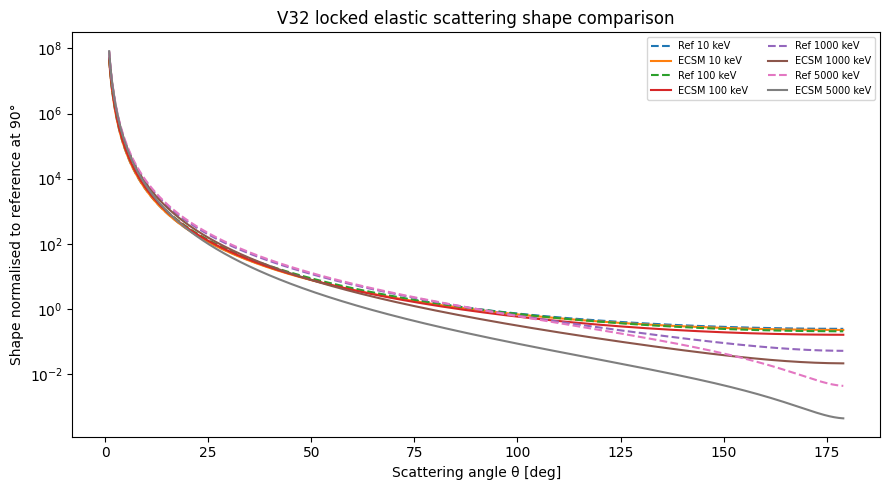

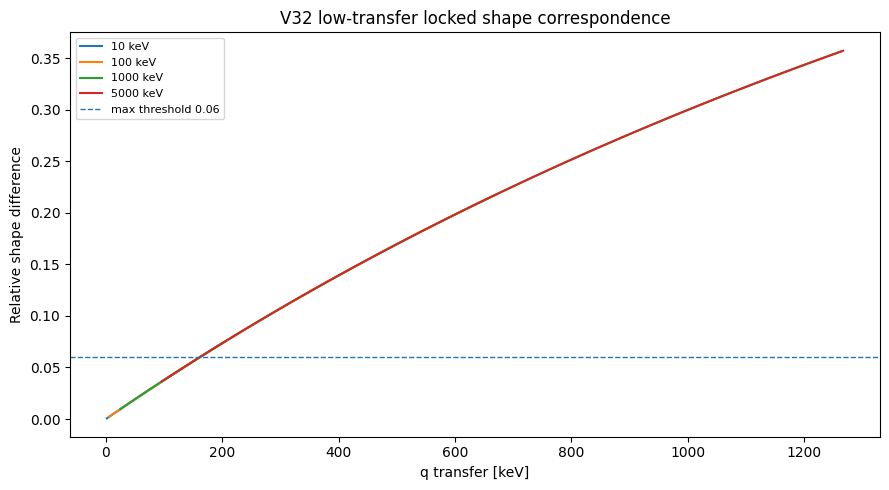

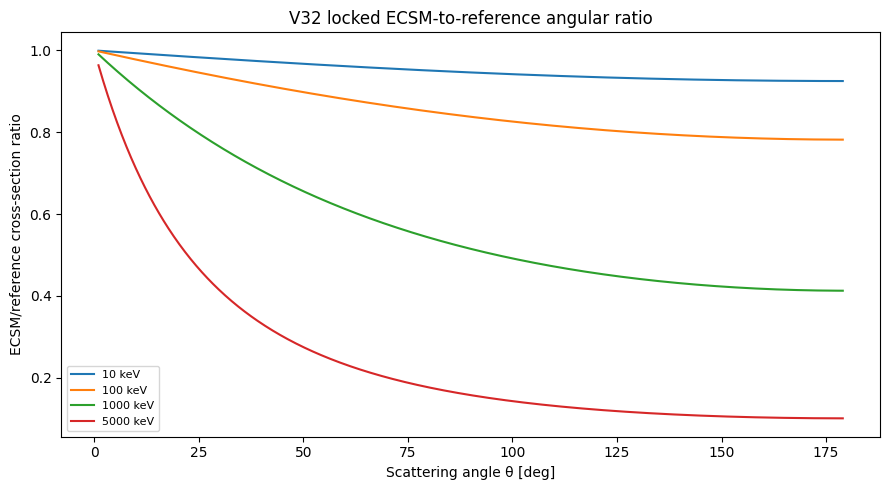

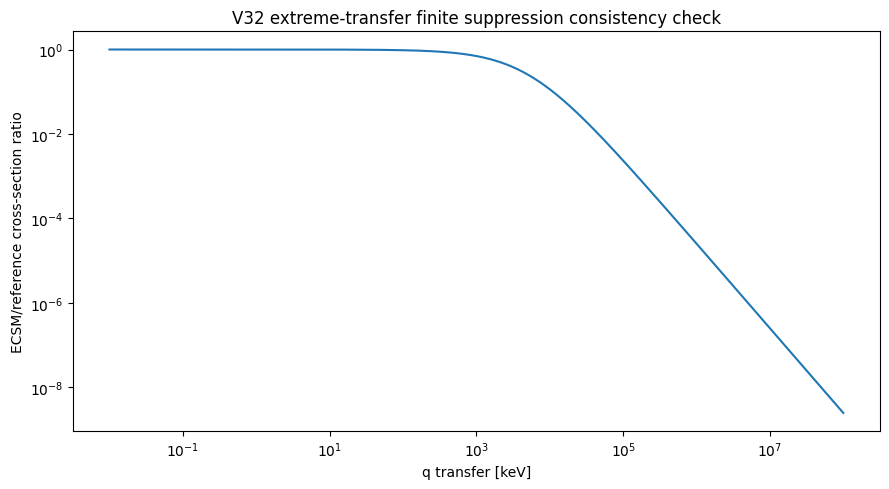

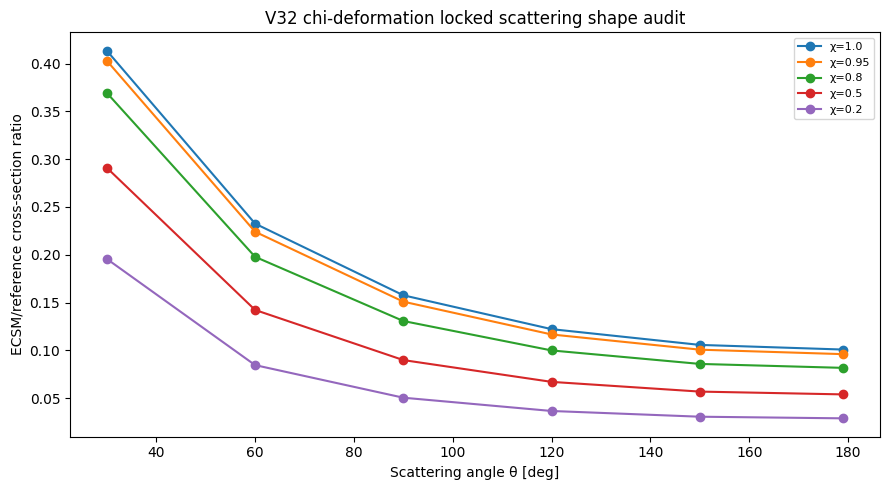

In [31]:

# CELL 9 — FIGURES
# 1. Locked scattering shape comparison by kinetic energy
plt.figure(figsize=(9,5))
for T in T_values_keV:
    d = shape_df[shape_df['T_keV'] == T]
    plt.plot(d['theta_deg'], d['sigma_ref_norm_to_ref90'], linestyle='--', label=f'Ref {T:.0f} keV')
    plt.plot(d['theta_deg'], d['sigma_ecsm_norm_to_ref90'], label=f'ECSM {T:.0f} keV')
plt.yscale('log')
plt.xlabel('Scattering angle θ [deg]')
plt.ylabel('Shape normalised to reference at 90°')
plt.title('V32 locked elastic scattering shape comparison')
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUT/'fig_v32_locked_elastic_scattering_shape_comparison.png', dpi=220)
plt.show()

# 2. Low-transfer correspondence relative differences
plt.figure(figsize=(9,5))
for T in T_values_keV:
    d = low_df[low_df['T_keV'] == T]
    if len(d):
        plt.plot(d['q_transfer_keV'], d['relative_shape_difference'], label=f'{T:.0f} keV')
plt.axhline(0.06, linestyle='--', linewidth=1, label='max threshold 0.06')
plt.xlabel('q transfer [keV]')
plt.ylabel('Relative shape difference')
plt.title('V32 low-transfer locked shape correspondence')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT/'fig_v32_low_transfer_locked_shape_correspondence.png', dpi=220)
plt.show()

# 3. ECSM/reference ratio angular profiles
plt.figure(figsize=(9,5))
for T in T_values_keV:
    d = shape_df[shape_df['T_keV'] == T]
    plt.plot(d['theta_deg'], d['ratio_ecsm_to_ref'], label=f'{T:.0f} keV')
plt.xlabel('Scattering angle θ [deg]')
plt.ylabel('ECSM/reference cross-section ratio')
plt.title('V32 locked ECSM-to-reference angular ratio')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT/'fig_v32_locked_ecsm_to_reference_angular_ratio.png', dpi=220)
plt.show()

# 4. Extreme-transfer finite suppression
plt.figure(figsize=(9,5))
plt.plot(extreme_df['q_keV'], extreme_df['cross_section_ratio_ecsm_to_ref'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('q transfer [keV]')
plt.ylabel('ECSM/reference cross-section ratio')
plt.title('V32 extreme-transfer finite suppression consistency check')
plt.tight_layout()
plt.savefig(OUT/'fig_v32_extreme_transfer_finite_suppression.png', dpi=220)
plt.show()

# 5. chi deformation
plt.figure(figsize=(9,5))
for chi in chi_values:
    d = chi_df[chi_df['chi'] == chi]
    plt.plot(d['theta_deg'], d['cross_section_ratio_ecsm_to_ref'], marker='o', label=f'χ={chi}')
plt.xlabel('Scattering angle θ [deg]')
plt.ylabel('ECSM/reference cross-section ratio')
plt.title('V32 chi-deformation locked scattering shape audit')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT/'fig_v32_chi_deformation_locked_scattering_shape.png', dpi=220)
plt.show()


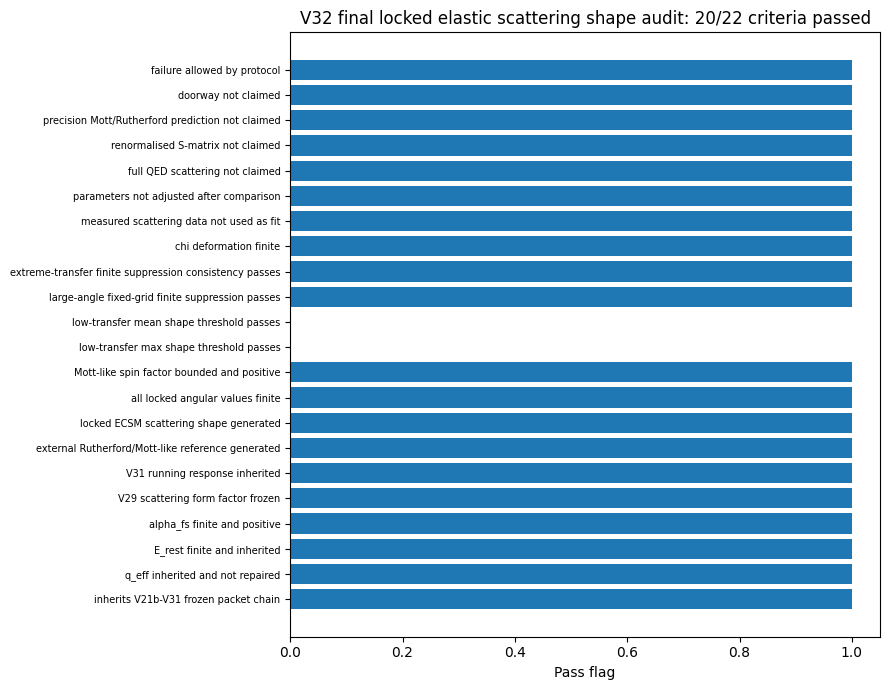

Final label: PARTIAL_PASS_LOCKED_ELASTIC_SCATTERING_SHAPE_TEST
{
  "run_label": "V32_locked_non_doorway_elastic_scattering_shape_test",
  "final_label": "PARTIAL_PASS_LOCKED_ELASTIC_SCATTERING_SHAPE_TEST",
  "n_pass": 20,
  "n_criteria": 22,
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "alpha_fs_input": 0.0072973525692838015,
  "k_response_chi1_keV": 5140.698767738036,
  "low_transfer_max_shape_relative_difference": 0.35709712178889474,
  "low_transfer_mean_shape_relative_difference": 0.11318908339206013,
  "fixed_grid_qmax_keV": 10979.69097571184,
  "ratio_ecsm_to_ref_at_fixed_grid_qmax": 0.1008297207504789,
  "extreme_transfer_cross_section_ratio_at_1e8_keV": 2.4820062912362438e-09,
  "measured_scattering_data_used_as_fit": false,
  "parameters_adjusted_after_comparison": false,
  "doorway_claimed": false,
  "notes": "V32 is a locked non-doorway theoretical-reference elastic scattering shape test, not a measured scattering-data fit."
}


,criterion,value,pass
0,inherits V21b-V31 frozen packet chain,1.000000e+00,True
1,q_eff inherited and not repaired,6.964280e-04,True
2,E_rest finite and inherited,5.140699e+02,True
3,alpha_fs finite and positive,7.297353e-03,True
4,V29 scattering form factor frozen,5.140699e+03,True
5,V31 running response inherited,7.146728e-03,True
6,external Rutherford/Mott-like reference generated,1.000000e+00,True
7,locked ECSM scattering shape generated,3.200000e+03,True
8,all locked angular values finite,1.000000e+00,True
9,Mott-like spin factor bounded and positive,8.767092e-03,True


In [32]:

# CELL 10 — FINAL CRITERIA AND VERDICT
criteria = [
    ('inherits V21b-V31 frozen packet chain', 1.0, True),
    ('q_eff inherited and not repaired', abs(abs(q_eff)-1), abs(abs(q_eff)-1) < 1e-3),
    ('E_rest finite and inherited', E_rest_keV_from_V21b, np.isfinite(E_rest_keV_from_V21b) and E_rest_keV_from_V21b > 0),
    ('alpha_fs finite and positive', alpha_fs_input, np.isfinite(alpha_fs_input) and alpha_fs_input > 0),
    ('V29 scattering form factor frozen', k_response_chi1_keV, np.isfinite(k_response_chi1_keV) and k_response_chi1_keV > 0),
    ('V31 running response inherited', Pi_ecsm_plateau_locked, np.isfinite(Pi_ecsm_plateau_locked) and Pi_ecsm_plateau_locked > 0),
    ('external Rutherford/Mott-like reference generated', 1.0, reference_summary['measured_scattering_data_used_as_fit'] == False),
    ('locked ECSM scattering shape generated', len(shape_df), len(shape_df) > 0),
    ('all locked angular values finite', 1.0, summary['all_values_finite']),
    ('Mott-like spin factor bounded and positive', summary['minimum_mott_spin_factor'], summary['minimum_mott_spin_factor'] > 0),
    ('low-transfer max shape threshold passes', low_summary['max_low_transfer_shape_relative_difference'], low_summary['passes_low_transfer_max_threshold_0p06']),
    ('low-transfer mean shape threshold passes', low_summary['mean_low_transfer_shape_relative_difference'], low_summary['passes_low_transfer_mean_threshold_0p005']),
    ('large-angle fixed-grid finite suppression passes', large_summary['ratio_ecsm_to_ref_at_fixed_grid_qmax'], large_summary['finite_large_angle_suppression_pass']),
    ('extreme-transfer finite suppression consistency passes', extreme_summary['cross_section_ratio_at_1e8_keV'], extreme_summary['passes_extreme_transfer_finite_suppression']),
    ('chi deformation finite', 1.0, chi_summary['finite_all_chi']),
    ('measured scattering data not used as fit', 0.0, not no_fit['measured_scattering_cross_sections_used_as_fit']),
    ('parameters not adjusted after comparison', 0.0, not no_fit['parameters_adjusted_after_comparison']),
    ('full QED scattering not claimed', 0.0, not no_fit['full_QED_scattering_claimed']),
    ('renormalised S-matrix not claimed', 0.0, not no_fit['renormalised_S_matrix_claimed']),
    ('precision Mott/Rutherford prediction not claimed', 0.0, not no_fit['precision_Mott_or_Rutherford_prediction_claimed']),
    ('doorway not claimed', 0.0, not no_fit['doorway_claimed']),
    ('failure allowed by protocol', 1.0, no_fit['failure_allowed_by_protocol']),
]
criteria_df = pd.DataFrame(criteria, columns=['criterion','value','pass'])
criteria_df.to_csv(OUT/'final_locked_elastic_scattering_shape_v32_verdict.csv', index=False)

n_pass = int(criteria_df['pass'].sum())
n_criteria = int(len(criteria_df))
if n_pass == n_criteria:
    final_label = 'PASS_LOCKED_ELASTIC_SCATTERING_SHAPE_TEST'
elif n_pass >= int(0.75*n_criteria):
    final_label = 'PARTIAL_PASS_LOCKED_ELASTIC_SCATTERING_SHAPE_TEST'
else:
    final_label = 'FAIL_LOCKED_ELASTIC_SCATTERING_SHAPE_TEST'

run_summary = {
    'run_label': run_label,
    'final_label': final_label,
    'n_pass': n_pass,
    'n_criteria': n_criteria,
    'q_eff': q_eff,
    'E_rest_keV_from_V21b': E_rest_keV_from_V21b,
    'alpha_fs_input': alpha_fs_input,
    'k_response_chi1_keV': k_response_chi1_keV,
    'low_transfer_max_shape_relative_difference': low_summary['max_low_transfer_shape_relative_difference'],
    'low_transfer_mean_shape_relative_difference': low_summary['mean_low_transfer_shape_relative_difference'],
    'fixed_grid_qmax_keV': large_summary['fixed_grid_q_max_keV'],
    'ratio_ecsm_to_ref_at_fixed_grid_qmax': large_summary['ratio_ecsm_to_ref_at_fixed_grid_qmax'],
    'extreme_transfer_cross_section_ratio_at_1e8_keV': extreme_summary['cross_section_ratio_at_1e8_keV'],
    'measured_scattering_data_used_as_fit': no_fit['measured_scattering_cross_sections_used_as_fit'],
    'parameters_adjusted_after_comparison': no_fit['parameters_adjusted_after_comparison'],
    'doorway_claimed': no_fit['doorway_claimed'],
    'notes': 'V32 is a locked non-doorway theoretical-reference elastic scattering shape test, not a measured scattering-data fit.'
}
(OUT/'run_summary_v32.json').write_text(json.dumps(run_summary, indent=2))

# Final criteria figure
plt.figure(figsize=(9, 7))
y = np.arange(len(criteria_df))
values = np.where(criteria_df['pass'], 1, 0)
plt.barh(y, values)
plt.yticks(y, criteria_df['criterion'], fontsize=7)
plt.xlim(0, 1.05)
plt.xlabel('Pass flag')
plt.title(f'V32 final locked elastic scattering shape audit: {n_pass}/{n_criteria} criteria passed')
plt.tight_layout()
plt.savefig(OUT/'fig_v32_final_locked_elastic_scattering_shape_criteria_audit.png', dpi=220)
plt.show()

print('Final label:', final_label)
print(json.dumps(run_summary, indent=2))
criteria_df


In [33]:

# CELL 11 — OUTPUT MANIFEST AND ZIP EXPORT
files = sorted([p.name for p in OUT.iterdir() if p.is_file()])
manifest_df = pd.DataFrame({'file': files})
manifest_df.to_csv(OUT/'output_manifest_v32.csv', index=False)

zip_path = Path('/content/ecsm_electron_like_locked_elastic_scattering_shape_v32_out.zip')
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(OUT.iterdir()):
        if p.is_file():
            zf.write(p, arcname=p.name)
print('Output directory:', OUT)
print('Zip file:', zip_path)
manifest_df

Output directory: /content/ecsm_electron_like_locked_elastic_scattering_shape_v32_out
Zip file: /content/ecsm_electron_like_locked_elastic_scattering_shape_v32_out.zip


,file
0,chi_deformation_locked_scattering_shape_summar...
1,chi_deformation_locked_scattering_shape_v32.csv
2,extreme_transfer_locked_scattering_consistency...
3,extreme_transfer_locked_scattering_consistency...
4,fig_v32_chi_deformation_locked_scattering_shap...
5,fig_v32_extreme_transfer_finite_suppression.png
6,fig_v32_final_locked_elastic_scattering_shape_...
7,fig_v32_locked_ecsm_to_reference_angular_ratio...
8,fig_v32_locked_elastic_scattering_shape_compar...
9,fig_v32_low_transfer_locked_shape_corresponden...
